# What an AI enineering needs from the cloud:

A AI workload only ever needs five things:

1. Compute to train and run models( especially GPUs and TPUs)
2. Storage for datasets, embeddings, and model artifacts.
3. A managed ML platform that ties training, tracking, and serving together.
4. A way to serve the model as an API others can call.
5. MLOps plumbing to automate, monitor and version everything.

Everything else(networking, IAM, billing) is supporting insfrastructure you learn as you go. If you understand these five categories on one cloud, you can pick up any other cloud in days.

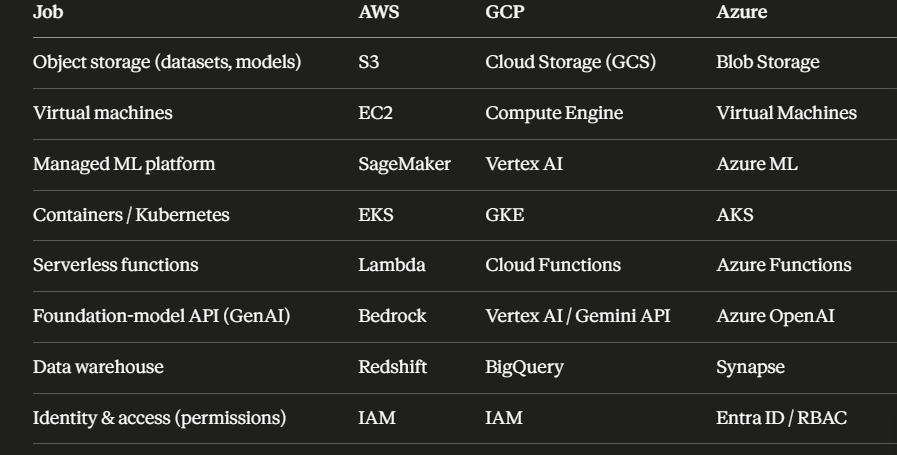 
* GCP tends to be favored in research/ data-heavy shops( BigQuery and TPUs are genuinely strong), 
* AWS dominates enterprise breadth, and 
* Azure wins where compnaies already run Microsoft and want OpenAI models. For your robotics/ agentic path, GCP (Vertex AI) and AWS (SageMaker + Bedrock) are the two highest-value to know.

- Compute : It is the place where it gets AI-specific, YOu'll request GPU instances (Nvidia A100, H100 on AWS p/g famillies, or via vertex AI on GCP) for training, and smaller/cheaper instances or serverless for inference. The key skills are picking the right  instance type, using spot preemtible instances to cut cost by 60-90 %, and not leaving GPUs running idle( the classic way to get a shocking bill).

- Storage for ML is mostly object storage -- S3 or GCS --- holding your training data and your  saved model weights. You'll learn to stream data from these buckets into training jobs rather than downloading everything locally.

- Serving is deploying your model behind an HTTPS endpint. You'll meet two patterns: managed endpoints(the platform handles autoscaling) and containerized serving(you packgae the model in Docker and run it on Kubernetes) or a serverless container service like Cloud Run/ AWS Fargate). Given your agentic /rag work, Cloud Run and AWS App Runner are great low-friction ways to ship an  inferenece API.

- MLOps wraps everything in automation: CI/CD pipelines that retrain and redeploy on new data, monitoring for model drift  and latency, and infrastructure - as -code (Terraform) so your setup is reproducible.


# Part 0 -- The two-minute foundation: Accounts, Regions, and the console.

An AWS account is your billing-and-ownership boundary. Everything you create inside one account, and that account gets one bill. When you sign up you get a root user(your email + password). Burn this into memory: you almost never use teh root user. It's the master key to the building. You use it once to set up a safer day-to-day identity(we'll do that in IAM) and then you lock it in a drawer. Using root for daily work is the AWS equivalent doing your grocery shopping while carrying the deed to your house.

A region is physical cluster of data centers in a geographic location -- `us-east-1` (Virginia) .~`ap-sourth-1`Mumbai, and so on. When you create something, it lives in a region. This matters for three reasons : latency  (pick a region first> FOr you in Dhaka ), cost (prices vary by region), and the occasional service that only launches in certain  regions first. FOr you in DHaka, `ap-south-1`(Mumbai) or `ap-southeast-1`: (Singapore) will usually give the lowest latency, though `us-east -1` is where AWS launches new things first and is often cheapest.

YOu interact with AWS three ways: the console (the web UI -- great for learning na dlooking around), the CLI commands in your terminal -- what you'll actually use day to day), and SDKs like boto3 (the Python library -- what your code uses to talk to AWS). As a Python -fluent  AI engineer, boto3 will become your closest companion. Same 